In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math
import seaborn as sns

In [2]:
data = pd.read_csv('data/Concrete_Data.csv')
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


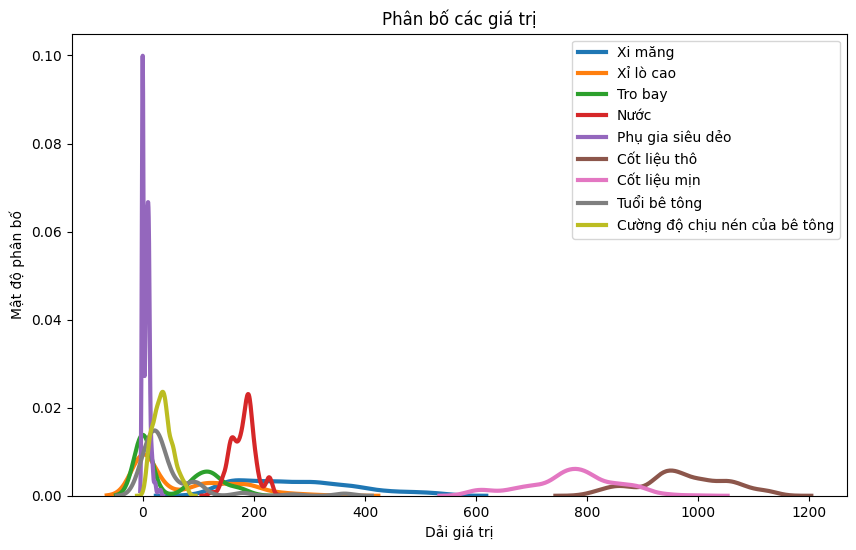

In [3]:
vn_columns = [
    "Xi măng",
    "Xỉ lò cao",
    "Tro bay",
    "Nước",
    "Phụ gia siêu dẻo",
    "Cốt liệu thô",
    "Cốt liệu mịn",
    "Tuổi bê tông",
    "Cường độ chịu nén của bê tông"
]
plt.figure(figsize=(10, 6))

for i in range(data.shape[1]):
    sns.kdeplot(data.iloc[:, i], label=vn_columns[i], linewidth=3)

plt.title('Phân bố các giá trị')
plt.xlabel('Dải giá trị')
plt.ylabel('Mật độ phân bố')
plt.legend()
plt.show()

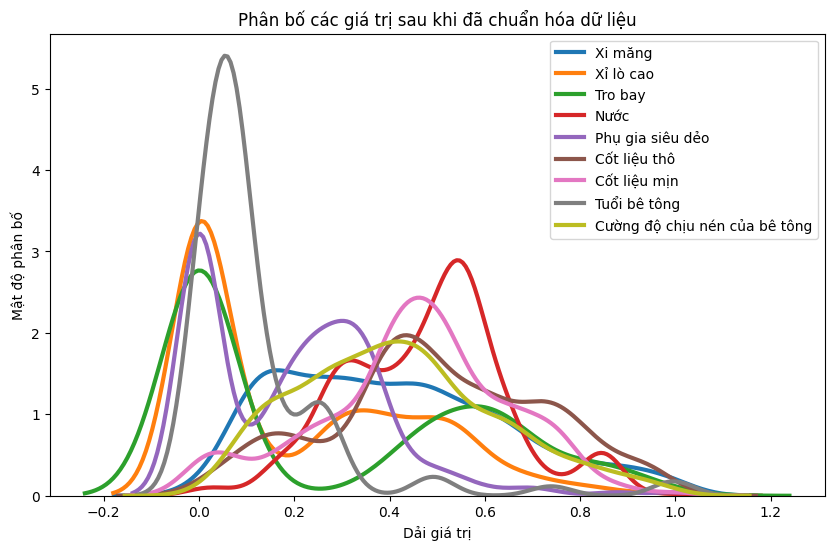

In [4]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X = X.values
X = (X - X.min(axis=0))/(X.max(axis=0) - X.min(axis=0))

y = y.values

data = (data - data.min(axis=0))/(data.max(axis=0) - data.min(axis=0))

plt.figure(figsize=(10, 6))

for i in range(data.shape[1]):
    sns.kdeplot(data.iloc[:, i], label=vn_columns[i], linewidth=3)

plt.title('Phân bố các giá trị sau khi đã chuẩn hóa dữ liệu')
plt.xlabel('Dải giá trị')
plt.ylabel('Mật độ phân bố')
plt.legend()
plt.show()

In [5]:
num_col = X.shape[1]
n = X.shape[0]
d = 1 + (num_col) + (num_col + math.comb(num_col, 2) ) + (num_col + 2 * math.comb(num_col, 2) + math.comb(num_col, 3))
converted_X = np.zeros(shape=(n, d))

converted_X[:, 0] = np.ones(n)

for i in range(n):
    k = 1
    for j in range(num_col):
        converted_X[i, k] = X[i, j]
        k += 1

        converted_X[i, k] = X[i, j] ** 2
        k += 1
        for m in range(j + 1, num_col):
            converted_X[i, k] = X[i, j] * X[i, m]
            k += 1

        converted_X[i, k] = X[i, j] ** 3
        k += 1
        for m in range(j + 1, num_col):
            converted_X[i, k] = X[i, j] ** 2 * X[i, m]
            k += 1
            converted_X[i, k] = X[i, j] * X[i, m] ** 2
            k += 1
            for l in range(m + 1, num_col):
                converted_X[i, k] = X[i, j] * X[i, m] * X[i, l]
                k += 1

In [6]:
X_train, X_test, y_train, y_test = train_test_split(converted_X, y, test_size=0.2, random_state=0)

eta   = 0.1
theta = 0.000001
w = np.zeros(shape=(d, 1))
n = X_train.shape[0]
k = 1
max_k = 30000000
while True:
    etaTemp = eta / (k / 10000 + 1)
    if k == max_k:
        break
    k += 1
    deltaJ = X_train.transpose() @ ((X_train @ w - y_train.reshape(-1, 1)) / X_train.shape[0])
    w = w - etaTemp * deltaJ
    if etaTemp * np.linalg.norm(deltaJ) < theta:
        break
print(k)


23119987


In [7]:
print('Tổng số mẫu: ', X.shape[0])
print('Số mẫu training: ', X_train.shape[0])
print('Số mẫu testing: ', X_test.shape[0])

Tổng số mẫu:  1030
Số mẫu training:  824
Số mẫu testing:  206


In [8]:
y_pred = X_test @ w
mse = mean_squared_error(y_pred, y_test)
print(mse)

48.55675127948473


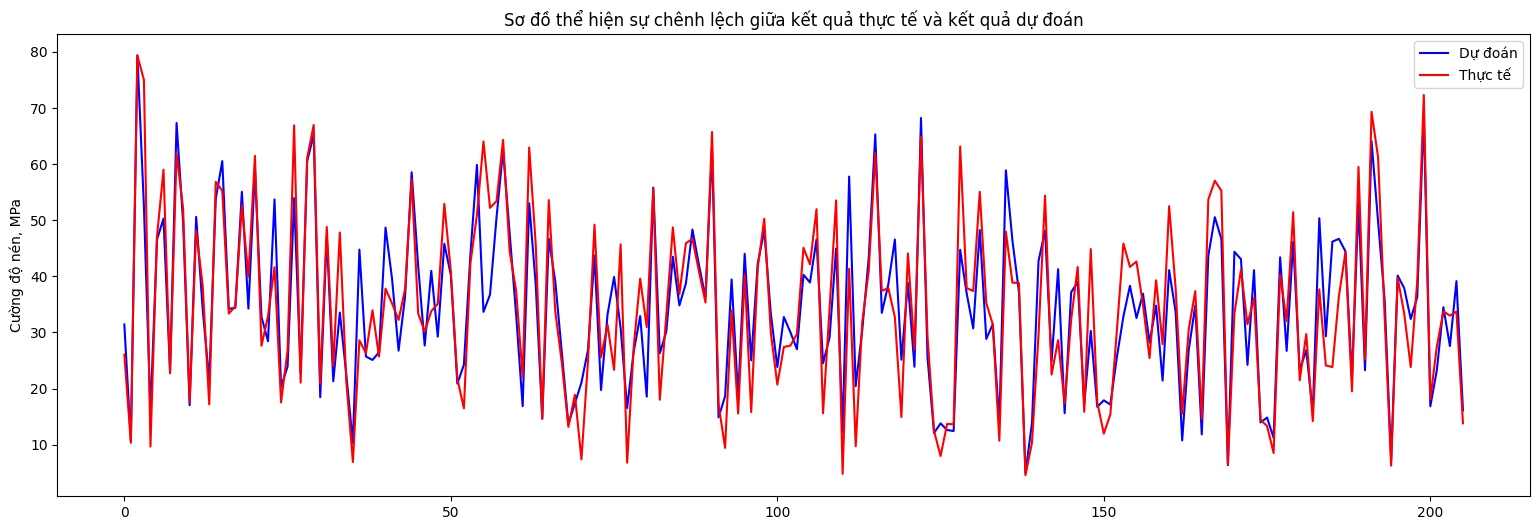

In [9]:
plt.figure(figsize=(19,6))
plt.plot(y_pred, color='blue', label='Dự đoán')
plt.plot(y_test, color='red', label='Thực tế')
plt.title('Sơ đồ thể hiện sự chênh lệch giữa kết quả thực tế và kết quả dự đoán')
plt.ylabel('Cường độ nén, MPa')
plt.legend()
plt.show()

In [10]:
print(w)

[[ 6.49832992e+00]
 [ 4.90181382e+01]
 [-4.50733150e+00]
 [ 4.86810568e+00]
 [ 1.56831350e+01]
 [-9.75342023e-01]
 [ 1.93626262e+01]
 [ 5.18391726e+00]
 [ 1.05703292e+01]
 [ 3.38870728e+01]
 [ 1.09156968e+01]
 [-1.08935386e+01]
 [ 1.99565389e+01]
 [ 1.25174467e+01]
 [ 5.79049945e+00]
 [ 7.64079960e-01]
 [-3.15169524e+01]
 [ 1.34686618e+01]
 [ 1.09669933e+01]
 [-5.04599890e+01]
 [ 5.57173666e+01]
 [ 1.57705604e+01]
 [ 4.98727565e+00]
 [-1.25303997e+01]
 [-2.19629677e+00]
 [ 4.08937493e+01]
 [-3.71330785e+01]
 [-3.11734732e+00]
 [ 2.06295258e+01]
 [-3.36114202e+01]
 [ 3.68217353e-01]
 [ 5.04832012e+00]
 [-1.58856752e+01]
 [-1.02523818e+01]
 [-3.89626573e+00]
 [ 9.75667234e+00]
 [-1.55032506e+00]
 [ 6.50142350e+00]
 [ 2.53184546e+01]
 [ 7.12782906e+00]
 [ 1.33596344e+01]
 [-4.31402659e+00]
 [-2.86245374e+01]
 [ 3.28358541e+01]
 [-3.47200537e+00]
 [-2.64022366e+01]
 [ 5.14966294e+00]
 [-8.95762189e-01]
 [ 1.65562201e+01]
 [ 3.96228061e+00]
 [ 1.08839334e+01]
 [-8.83078359e+00]
 [ 1.8944548

In [11]:
print(y_pred)

[[31.42809977]
 [10.68619635]
 [79.3716368 ]
 [52.4525809 ]
 [15.61227525]
 [46.55314442]
 [50.28393357]
 [23.06793415]
 [67.31692093]
 [49.65667627]
 [17.04359214]
 [50.59522923]
 [34.13404629]
 [21.37428887]
 [53.80900551]
 [60.52001792]
 [34.20415945]
 [34.40673127]
 [55.0586567 ]
 [34.24826157]
 [58.93544443]
 [32.78614367]
 [28.44748395]
 [53.69772357]
 [20.32253717]
 [23.95366895]
 [53.92963629]
 [22.75906364]
 [60.52001792]
 [65.2464883 ]
 [18.47964162]
 [47.18831727]
 [21.32332443]
 [33.54614298]
 [22.42290621]
 [10.3304766 ]
 [44.76548846]
 [25.72241895]
 [25.11183609]
 [26.46289764]
 [48.68764458]
 [39.53514615]
 [26.76351014]
 [36.48343268]
 [58.53635254]
 [41.84436783]
 [27.67423815]
 [40.98196037]
 [29.26623543]
 [45.80029946]
 [40.24188548]
 [20.88778659]
 [24.24682291]
 [43.95164549]
 [59.84474841]
 [33.6630061 ]
 [36.74693207]
 [50.51360091]
 [62.43113026]
 [47.84827579]
 [33.1676818 ]
 [16.86920732]
 [53.01630846]
 [38.57381102]
 [14.66241296]
 [46.67125621]
 [39.06272